#### Imports

In [96]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import copy

from tqdm import tqdm
from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
import pickle
from sklearn.model_selection import train_test_split

import globals
import utils

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", device)

Current device: cuda


In [97]:
importlib.reload(globals)
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Master_Thesis\\utils.py'>

In [98]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [99]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))

# first split: train (80%) and temp (20%)
X_tr, X_temp, Y_tr, Y_temp = train_test_split(X, Y_resh, test_size=0.2, shuffle=True, random_state=42)

# second split: validation (10%) and test (10%)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, shuffle=True, random_state=42)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("wavelengths shape:", wavelengths.shape)
print()
print("X_tr shape:", X_tr.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print()
print("Y_tr shape:", Y_tr.shape)
print("Y_val shape:", Y_val.shape)
print("Y_test shape:", Y_test.shape)

X shape: (500, 9)
Y shape: (500, 25230)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (50, 9)
X_test shape: (50, 9)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)


#### Convolutional Neural Network Pipeline

<ol>
    <li><b>Model and Dataset Definition</b>: Encoder-Decoder architecture.</li>
    <li><b>Training/Validation</b>: train loop with validation to choose the best model.</li>
    <li><b>External Testing</b> of the best selected model.</li>
</ol>

In [100]:
class Dataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [101]:
class Encoder(nn.Module):
    def __init__(self, z_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(9, 64),
            nn.SiLU(),
            nn.Linear(64, 128),
            nn.SiLU(),
            nn.Linear(128, z_dim),
            nn.SiLU()
        )

    def forward(self, x):
        return self.net(x)

In [102]:
class SpectralDecoder1(nn.Module):
    def __init__(self, z_dim=128, channels=64):
        super().__init__()
        self.fc = nn.Linear(z_dim, channels * 64)

        # processing at low-res (64 --> 64 length)
        self.initial_conv = nn.Sequential(
            nn.Conv1d(channels, 64, kernel_size=5, padding=2),
            nn.GroupNorm(8, 64),
            nn.SiLU()
        )

        # progressively upsample the sequence length
        # formula: Out = (In - 1) * stride - 2 * padding + kernel_size
        self.upsample_pipeline = nn.Sequential(
            # 64 -> 256 length
            nn.ConvTranspose1d(64, 32, kernel_size=6, stride=4, padding=1), 
            nn.GroupNorm(8, 32),
            nn.SiLU(),
            
            # 256 -> 1024 length
            nn.ConvTranspose1d(32, 16, kernel_size=6, stride=4, padding=1),
            nn.GroupNorm(4, 16),
            nn.SiLU(),

            # 1024 -> 4096 length
            nn.ConvTranspose1d(16, 8, kernel_size=6, stride=4, padding=1),
            nn.GroupNorm(2, 8),
            nn.SiLU()
        )

        # final adjustment to hit exactly 4205 and map to 1 output channel
        self.final_conv = nn.Conv1d(8, 1, kernel_size=5, padding=2)

    def forward(self, z):
        x = self.fc(z).view(z.size(0), 64, 64)
        x = self.initial_conv(x)
        x = self.upsample_pipeline(x) # Shape is now (N, 8, 4096)
        
        # from 4096, use a tiny interpolation just to cover the last 109 points
        x = F.interpolate(x, size=4205, mode="linear", align_corners=False)
        
        x = self.final_conv(x).squeeze(1)
        return x
    
class EmulatorSet1(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()

        # 6 decoders, one for each radiative transfer function
        self.decoders = nn.ModuleList([
            SpectralDecoder1() for _ in range(globals.N_FUNCTIONS)
        ])

    def forward(self, x):
        z = self.encoder(x)
        # returns a list of 6 tensors, each with shape (N, 4205)
        return [dec(z) for dec in self.decoders]

In [103]:
class SpectralDecoder2(nn.Module):
    def __init__(self, z_dim=128, n_components=10):
        super().__init__()
        # map the latent space to the PCA coefficients
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.SiLU(),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Linear(128, n_components) # output shape: (N, 10)
        )

    def forward(self, z):
        return self.net(z)

class EmulatorSet2(nn.Module):
    def __init__(self, n_components=10):
        super().__init__()
        self.encoder = Encoder()
        
        self.decoders = nn.ModuleList([
            SpectralDecoder2(z_dim=128, n_components=n_components) for _ in range(globals.N_FUNCTIONS)
        ])

    def forward(self, x):
        z = self.encoder(x)
        # returns a list of 6 tensors, each with shape (N, 10)
        return [dec(z) for dec in self.decoders]

In [104]:
# quick model test
model = EmulatorSet2().to(device)
model.eval()

# dummy input: (batch_size, 9)
X_tr_tensor = torch.tensor(X_tr, dtype=torch.float32).to(device)

with torch.no_grad():
    y_pred = model(X_tr_tensor)

# y is a list of 6 tensors, each (B, 4205)
for i, yi in enumerate(y_pred):
    print(i+1, yi.shape)

summary(model, input_size=(1, globals.N_INPUTS))

1 torch.Size([400, 10])
2 torch.Size([400, 10])
3 torch.Size([400, 10])
4 torch.Size([400, 10])
5 torch.Size([400, 10])
6 torch.Size([400, 10])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 64]             640
              SiLU-2                [-1, 1, 64]               0
            Linear-3               [-1, 1, 128]           8,320
              SiLU-4               [-1, 1, 128]               0
            Linear-5               [-1, 1, 128]          16,512
              SiLU-6               [-1, 1, 128]               0
           Encoder-7               [-1, 1, 128]               0
            Linear-8               [-1, 1, 256]          33,024
              SiLU-9               [-1, 1, 256]               0
           Linear-10               [-1, 1, 128]          32,896
             SiLU-11               [-1, 1, 128]               0
           Linear-12   

In [105]:
# define datasets and dataloaders
train_ds = Dataset(X_tr, Y_tr)
val_ds = Dataset(X_val, Y_val)

print("Train dataset length:", len(train_ds))
print("Val dataset length:", len(val_ds))

# get item check
x, y = train_ds.__getitem__(0)
print("Input shape:", x.shape)
print("Output shape:", y.shape)

train_dl = DataLoader(train_ds, batch_size=4, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=4)

Train dataset length: 400
Val dataset length: 50
Input shape: torch.Size([9])
Output shape: torch.Size([6, 4205])


In [106]:
class MRELoss(nn.Module):
    def __init__(self, min_denominator=1e-3, epsilon=1e-8):
        super().__init__()
        self.min_denominator = min_denominator
        self.epsilon = epsilon

    def forward(self, pred, target):
        relative_error = torch.abs(pred - target) / (torch.abs(target) + self.epsilon)
        return torch.mean(relative_error)

In [ ]:
# train loop configurations
n_epochs = 100
model = EmulatorSet1().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# criterion = MRELoss(min_denominator=1e-3, epsilon=1e-8)
criterion = torch.nn.MSELoss()
history = defaultdict(list)

# scheduler setup for learning rate reduction on plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',
    factor=0.2,      # Cut LR by 5x when stalling
    patience=5,      # Wait 5 epochs before cutting
)

# early stopping setup
patience = 25
best_val_loss = float("inf")
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

epsilon = 1e-8

# pca_list, Y_tr_pca_list, Y_val_pca_list = utils.apply_pca(Y_tr, Y_val, n_components=10, kernel=None, gamma=1e-2, alpha=1e-1, degree=3)

# X_tr_scaled, X_val_scaled, x_scaler = utils.scale_input_data(X_tr, X_val, scale_type="minmax")
# Y_tr_reduced_scaled_list, Y_val_reduced_scaled_list, y_scalers = utils.scale_output_data(Y_tr_pca_list, Y_val_pca_list, scale_type="minmax")

# # recreate shape of (N, 6, 10) for the dataloader
# Y_tr_reduced_scaled_list = np.stack(Y_tr_reduced_scaled_list, axis=1)
# Y_val_reduced_scaled_list = np.stack(Y_val_reduced_scaled_list, axis=1)

# train_ds = Dataset(X_tr_scaled, Y_tr_reduced_scaled_list)
# val_ds = Dataset(X_val_scaled, Y_val_reduced_scaled_list)
# train_dl = DataLoader(train_ds, batch_size=4, shuffle=True)
# val_dl = DataLoader(val_ds, batch_size=4)

for epoch in range(n_epochs):
    # ==================== TRAINING PHASE ====================
    model.train()
    epoch_train_loss = 0.0
    epoch_train_mre = 0.0

    train_tqdm = tqdm(train_dl, desc=f"Epoch {epoch+1}/{n_epochs} [Train]")
    for X_batch, Y_batch in train_tqdm:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        optimizer.zero_grad()
        Y_pred_list = model(X_batch)
        
        loss = 0.0
        batch_mre = 0.0
        
        for i, pred in enumerate(Y_pred_list):
            y_true = Y_batch[:, i, :]
            
            # 1. MSE Component
            loss += criterion(pred, y_true) / len(Y_pred_list)
            
            # 2. MRE Component
            relative_error = torch.abs(pred - y_true) / (torch.abs(y_true) + epsilon)
            batch_mre += torch.mean(relative_error).item() / len(Y_pred_list)
            
        loss.backward()
        optimizer.step()

        # track metrics weighted by batch size for accuracy across varying batches
        epoch_train_loss += loss.item() * X_batch.size(0)
        epoch_train_mre += batch_mre * X_batch.size(0)
        
        train_tqdm.set_postfix({
            "loss": loss.item(), 
            "mre": batch_mre
        })

    # average metrics over the entire dataset
    epoch_train_loss /= len(train_ds)
    epoch_train_mre /= len(train_ds)
    history["train_loss"].append(epoch_train_loss)
    history["train_mre"].append(epoch_train_mre)

    # ==================== VALIDATION PHASE ====================
    model.eval()
    epoch_val_loss = 0.0
    epoch_val_mre = 0.0
    
    val_tqdm = tqdm(val_dl, desc=f"Epoch {epoch+1}/{n_epochs} [Val]")
    with torch.no_grad():
        for X_batch, Y_batch in val_tqdm:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            Y_pred_list = model(X_batch)
            
            loss = 0.0
            batch_mre = 0.0
            for i, pred in enumerate(Y_pred_list):
                y_true = Y_batch[:, i, :]
                loss += criterion(pred, y_true) / len(Y_pred_list)
                
                relative_error = torch.abs(pred - y_true) / (torch.abs(y_true) + epsilon)
                batch_mre += torch.mean(relative_error).item() / len(Y_pred_list)
                
            epoch_val_loss += loss.item() * X_batch.size(0)
            epoch_val_mre += batch_mre * X_batch.size(0)
            
            val_tqdm.set_postfix({
                "loss": loss.item(), 
                "mre": batch_mre
            })
            
    epoch_val_loss /= len(val_ds)
    scheduler.step(epoch_val_loss)
    epoch_val_mre /= len(val_ds)
    history["val_loss"].append(epoch_val_loss)
    history["val_mre"].append(epoch_val_mre)

    print(f"--- Epoch {epoch+1} Summary ---")
    print(f"Train Loss: {epoch_train_loss:.6f} | Train MRE: {epoch_train_mre:.4f}")
    print(f"Val Loss:   {epoch_val_loss:.6f} | Val MRE:   {epoch_val_mre:.4f}")

    # ==================== EARLY STOPPING LOGIC ====================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        print("--> Validation loss decreased. Saving best model weights!")
    else:
        patience_counter += 1
        print(f"--> No improvement in val loss. Patience counter: {patience_counter}/{patience}")
        
        if patience_counter >= patience:
            print("\n!!! Early stopping triggered. Training halted. !!!")
            break
    print()

# reload the best weights found during the run before evaluating on test set
model.load_state_dict(best_model_wts)
print("Loaded best model weights for subsequent testing.")

Epoch 1/100 [Val]: 100%|██████████| 13/13 [00:00<00:00, 188.26it/s, loss=1.77e+5, mre=9.5e+3]


--- Epoch 1 Summary ---
Train Loss: 128738.26 | Train MRE: 74345.33
Val Loss:   134430.81 | Val MRE:   68003.99
--> Validation loss decreased. Saving best model weights!



Epoch 2/100 [Val]: 100%|██████████| 13/13 [00:00<00:00, 188.41it/s, loss=1.75e+5, mre=1.69e+4]


--- Epoch 2 Summary ---
Train Loss: 127021.82 | Train MRE: 102889.27
Val Loss:   132389.83 | Val MRE:   144096.90
--> Validation loss decreased. Saving best model weights!



Epoch 3/100 [Val]: 100%|██████████| 13/13 [00:00<00:00, 188.41it/s, loss=1.72e+5, mre=2.56e+4]


...

--- Epoch 98 Summary ---
Train Loss: 512.06 | Train MRE: 676988.83
Val Loss:   543.64 | Val MRE:   495863.76
--> Validation loss decreased. Saving best model weights!



Epoch 99/100 [Val]: 100%|██████████| 13/13 [00:00<00:00, 187.02it/s, loss=745, mre=7.74e+4]


--- Epoch 99 Summary ---
Train Loss: 497.37 | Train MRE: 637935.55
Val Loss:   545.10 | Val MRE:   521390.70
--> No improvement in val loss. Patience counter: 1/25



Epoch 100/100 [Val]: 100%|██████████| 13/13 [00:00<00:00, 185.70it/s, loss=785, mre=8.29e+4]

--- Epoch 100 Summary ---
Train Loss: 548.62 | Train MRE: 615958.83
Val Loss:   577.86 | Val MRE:   533221.85
--> No improvement in val loss. Patience counter: 2/25

Loaded best model weights for subsequent testing.


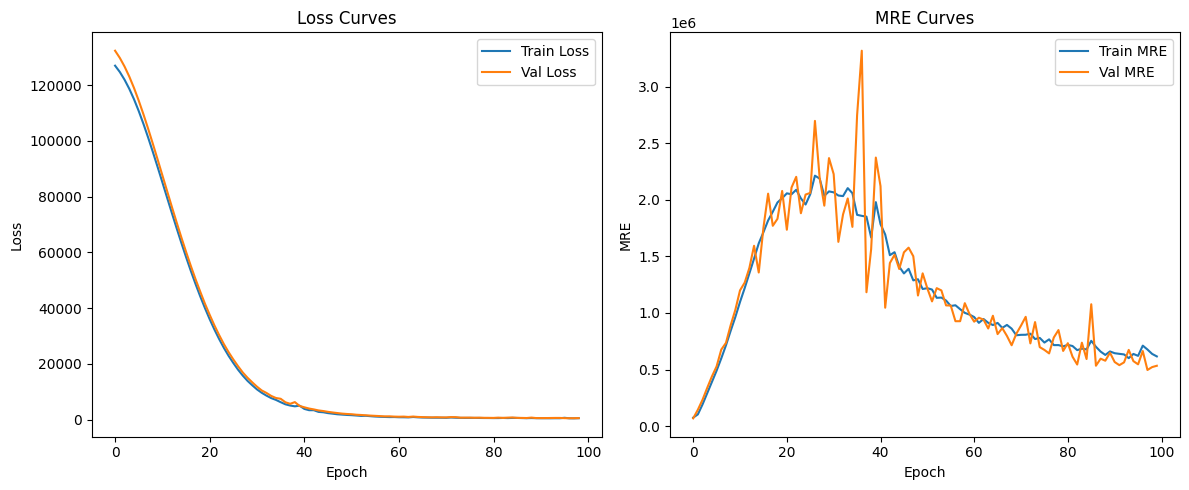

In [108]:
# history plotting
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"][1:], label="Train Loss")
plt.plot(history["val_loss"][1:], label="Val Loss")
plt.title("Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_mre"], label="Train MRE")
plt.plot(history["val_mre"], label="Val MRE")
plt.title("MRE Curves")
plt.xlabel("Epoch")
plt.ylabel("MRE")
plt.legend()

plt.tight_layout()
plt.show()

In [109]:
# test on test set
test_ds = Dataset(X_test, Y_test)
test_dl = DataLoader(test_ds, batch_size=4)

# test loop
model.eval()
test_loss = 0.0
test_mre = 0.0
test_tqdm = tqdm(test_dl, desc="Testing")
with torch.no_grad():
    for X_batch, Y_batch in test_tqdm:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        Y_pred_list = model(X_batch)
        
        loss = 0.0
        batch_mre = 0.0
        
        for i, pred in enumerate(Y_pred_list):
            y_true = Y_batch[:, i, :]
            loss += criterion(pred, y_true) / len(Y_pred_list)
            
            relative_error = torch.abs(pred - y_true) / (torch.abs(y_true) + epsilon)
            batch_mre += torch.mean(relative_error).item() / len(Y_pred_list)
            
        test_loss += loss.item() * X_batch.size(0)
        test_mre += batch_mre * X_batch.size(0)
        
        test_tqdm.set_postfix({
            "loss": loss.item(),
            "mre": batch_mre
        })
test_loss /= len(test_ds)
test_mre /= len(test_ds)
print(f"\nFinal Test Loss: {test_loss:.2f} | Final Test MRE: {test_mre:.2f}")

Testing: 100%|██████████| 13/13 [00:00<00:00, 60.74it/s, loss=488, mre=5.26e+5]


Final Test Loss: 467.00 | Final Test MRE: 476714.50


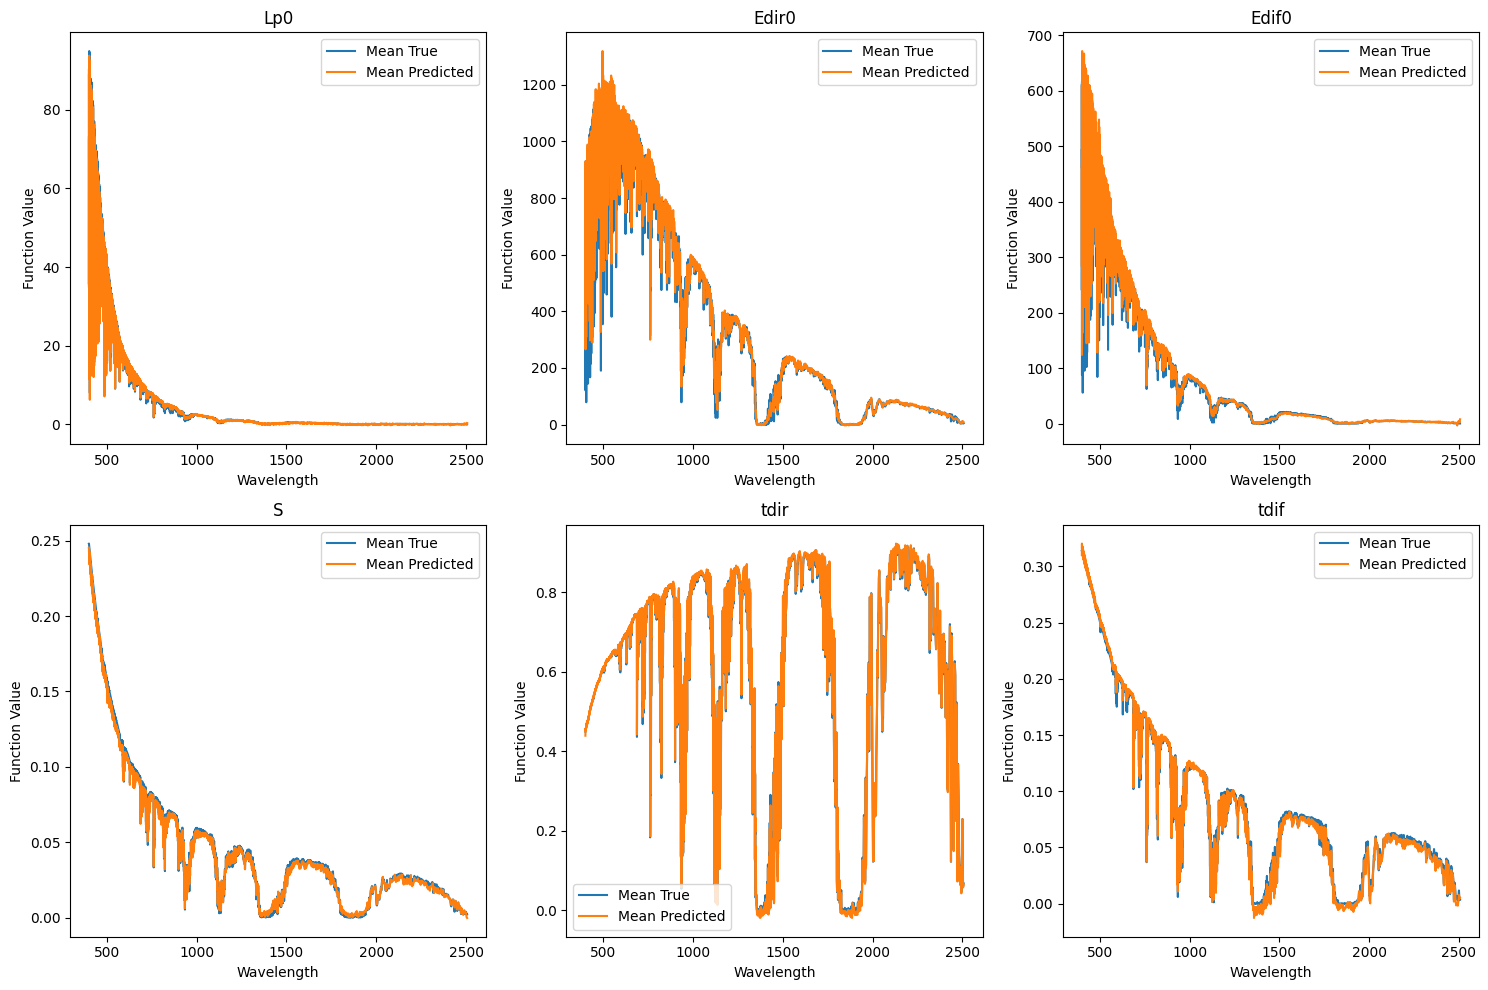

In [110]:
# predict on test set for visualization
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
with torch.no_grad():
    y_pred = model(X_test_tensor)

plt.figure(figsize=(15, 10))
for i in range(globals.N_FUNCTIONS):  # iterate over functions

    plt.subplot(2, 3, i + 1)

    plt.plot(wavelengths, np.mean(Y_test[:, i, :], axis=0), label="Mean True")
    plt.plot(wavelengths, np.mean(y_pred[i].squeeze(0).cpu().numpy(), axis=0), label="Mean Predicted")

    plt.title(f"{function_names[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
    plt.legend()

plt.tight_layout()
plt.show()